In [1]:
import numpy as np
import pandas as pd
import scipy.stats as ss
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [2]:
df=sns.load_dataset("iris")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [3]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [4]:
df.groupby("species").sepal_length.describe()

,count,mean,std,min,25%,50%,75%,max
species,,,,,,,,
setosa,50.0,5.006,0.352490,4.3,4.800,5.0,5.2,5.8
versicolor,50.0,5.936,0.516171,4.9,5.600,5.9,6.3,7.0
virginica,50.0,6.588,0.635880,4.9,6.225,6.5,6.9,7.9


In [5]:
df.species.unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

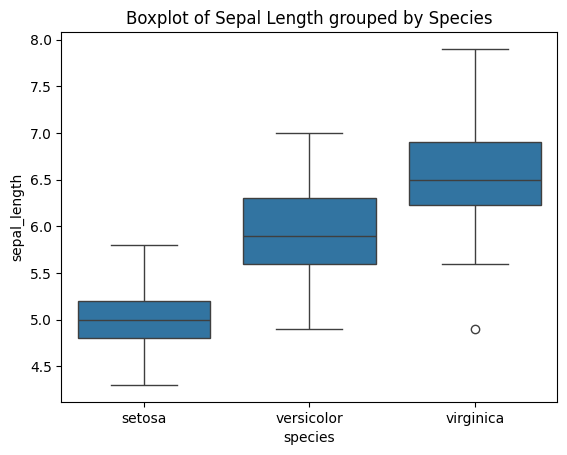

In [6]:
sns.boxplot(x='species',y='sepal_length',data=df)
plt.title("Boxplot of Sepal Length grouped by Species")
plt.show()

In [7]:
import statsmodels.formula.api as smf
model=smf.ols('sepal_length~C(species)',data=df).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           sepal_length   R-squared:                       0.619
Model:                            OLS   Adj. R-squared:                  0.614
Method:                 Least Squares   F-statistic:                     119.3
Date:                Mon, 12 Jan 2026   Prob (F-statistic):           1.67e-31
Time:                        15:32:09   Log-Likelihood:                -111.73
No. Observations:                 150   AIC:                             229.5
Df Residuals:                     147   BIC:                             238.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                    5.0060      0.073     68.762      0.000       4.862       5.150
C(species)[T.versicolor]     0.9300      0.103      9.033      0.000       0.727       1.133
C(species)[T.virginica]      1.5820      0.103     15.366      0.000       1.379       1.785
==============================================================================
Omnibus:                        1.188   Durbin-Watson:                   2.043
Prob(Omnibus):                  0.552   Jarque-Bera (JB):                0.785
Skew:                           0.119   Prob(JB):                        0.675
Kurtosis:                       3.263   Cond. No.                         3.73
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [9]:
anova_1w=sm.stats.anova_lm(model)
print(anova_1w)
anova_pval=anova_1w.loc['C(species)','PR(>F)']
alpha=0.05

if anova_pval>alpha:
    print(f"Pvalue: {anova_pval} so fail to reject H0: All species have equal mean sepal length")
else:
    print(f"Pvalue: {anova_pval} so reject H0: All species have equal mean sepal length")

               df     sum_sq    mean_sq           F        PR(>F)
C(species)    2.0  63.212133  31.606067  119.264502  1.669669e-31
Residual    147.0  38.956200   0.265008         NaN           NaN
Pvalue: 1.6696691907702547e-31 so reject H0: All species have equal mean sepal length


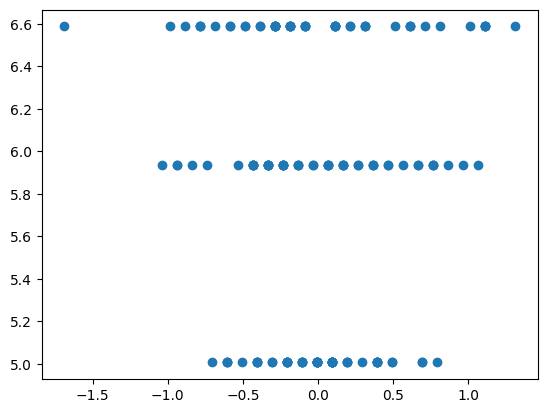

In [10]:
plt.scatter(model.resid,model.fittedvalues)

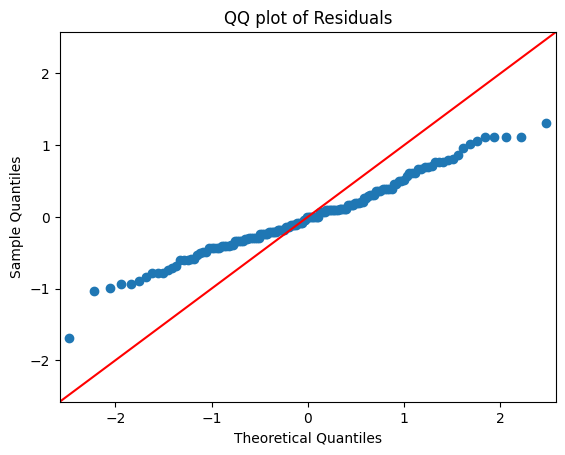

In [11]:
sm.qqplot(model.resid,line='45')
plt.title("QQ plot of Residuals")
plt.show()

In [12]:
stat, p_val=ss.shapiro(model.resid)
if p_val>alpha:
    print(f"Pvalue: {p_val:.4f} so fail to reject H0: Residuals following Normal Distribution")
else:
    print(f"Pvalue: {p_val:.4f} so reject H0: Residuals following Normal Distribution")

Pvalue: 0.2189 so fail to reject H0: Residuals following Normal Distribution


In [16]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
print(pairwise_tukeyhsd(df.sepal_length,df.species))

   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1     group2   meandiff p-adj lower  upper  reject
---------------------------------------------------------
    setosa versicolor     0.93   0.0 0.6862 1.1738   True
    setosa  virginica    1.582   0.0 1.3382 1.8258   True
versicolor  virginica    0.652   0.0 0.4082 0.8958   True
---------------------------------------------------------


In [27]:
n=30
mu1, mu2, mu3 =10, 20, 30
sig =10
G1=np.random.normal(mu1,sig,n)
G2=np.random.normal(mu2,sig,n)
G3=np.random.normal(mu3,sig,n)
df2=pd.DataFrame({"Y":np.concatenate([G1,G2,G3]), 
               "X" :np.repeat(["G1","G2","G3"],n)})
#df2.head()

In [37]:
model2=smf.ols('Y~C(X)',data=df2).fit()
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.325
Model:                            OLS   Adj. R-squared:                  0.310
Method:                 Least Squares   F-statistic:                     20.98
Date:                Mon, 12 Jan 2026   Prob (F-statistic):           3.67e-08
Time:                        16:15:10   Log-Likelihood:                -340.47
No. Observations:                  90   AIC:                             686.9
Df Residuals:                      87   BIC:                             694.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     11.2093      1.975      5.677      0.000       7.284      15.134
C(X)[T.G2]     8.7877      2.793      3.147      0.002       3.237      14.338
C(X)[T.G3]    18.0867      2.793      6.477      0.000      12.536      23.637
==============================================================================
Omnibus:                        0.710   Durbin-Watson:                   2.073
Prob(Omnibus):                  0.701   Jarque-Bera (JB):                0.779
Skew:                          -0.201   Prob(JB):                        0.677
Kurtosis:                       2.785   Cond. No.                         3.73
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
anova_1w2=sm.stats.anova_lm(model2)
print(anova_1w2)
anova_pval2=anova_1w2.loc['C(X)','PR(>F)']
alpha=0.05

if anova_pval2>alpha:
    print(f"Pvalue: {anova_pval} so fail to reject H0: All groups have equal mean")
else:
    print(f"Pvalue: {anova_pval} so reject H0: All groups have equal mean")